In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\hjgxh\OneDrive\Документы\GitHub\DPP-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "rifatalam3/gold-price-trends" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 84.0k/84.0k [00:00<00:00, 420kB/s]

Extracting files...
Loading dataset from C:\Users\hjgxh\.cache\kagglehub\datasets\rifatalam3\gold-price-trends\versions\1 to ../data/raw\gold-price-trends
Moving file: C:\Users\hjgxh\.cache\kagglehub\datasets\rifatalam3\gold-price-trends\versions\1\finalgolddata.csv to c:\Users\hjgxh\OneDrive\Документы\GitHub\DPP-1\notebooks\../data/raw\gold-price-trends
Files moved to '../data/raw\gold-price-trends' directory.


In [3]:
files

['finalgolddata.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(6399, 6)

'Description'

,count,mean,std,min,25%,50%,75%,max
Open,6399.0,1274.89,782.87,255.0,651.00,1251.6,1694.70,5415.7
High,6399.0,1281.73,788.80,256.1,653.65,1256.2,1706.10,5586.2
Low,6399.0,1267.91,777.09,255.0,649.15,1244.8,1683.25,5334.9
Close,6399.0,1274.96,783.12,255.1,651.70,1251.1,1695.65,5377.3
Volume,6399.0,4282.54,24051.64,0.0,23.00,117.0,450.50,386334.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Date,object,0,6399,"[21-10-05, 17-06-08, 20-12-19]"
Open,float64,0,5091,"[1622.599976, 2503.5, 1156.300049]"
High,float64,0,5075,"[1243.699951, 2765.0, 1797.0]"
Low,float64,0,5039,"[296.0, 1561.300049, 1196.599976]"
Close,float64,0,5144,"[2334.800049, 273.7000122, 1569.199951]"
Volume,int64,0,1635,"[14, 320, 51]"


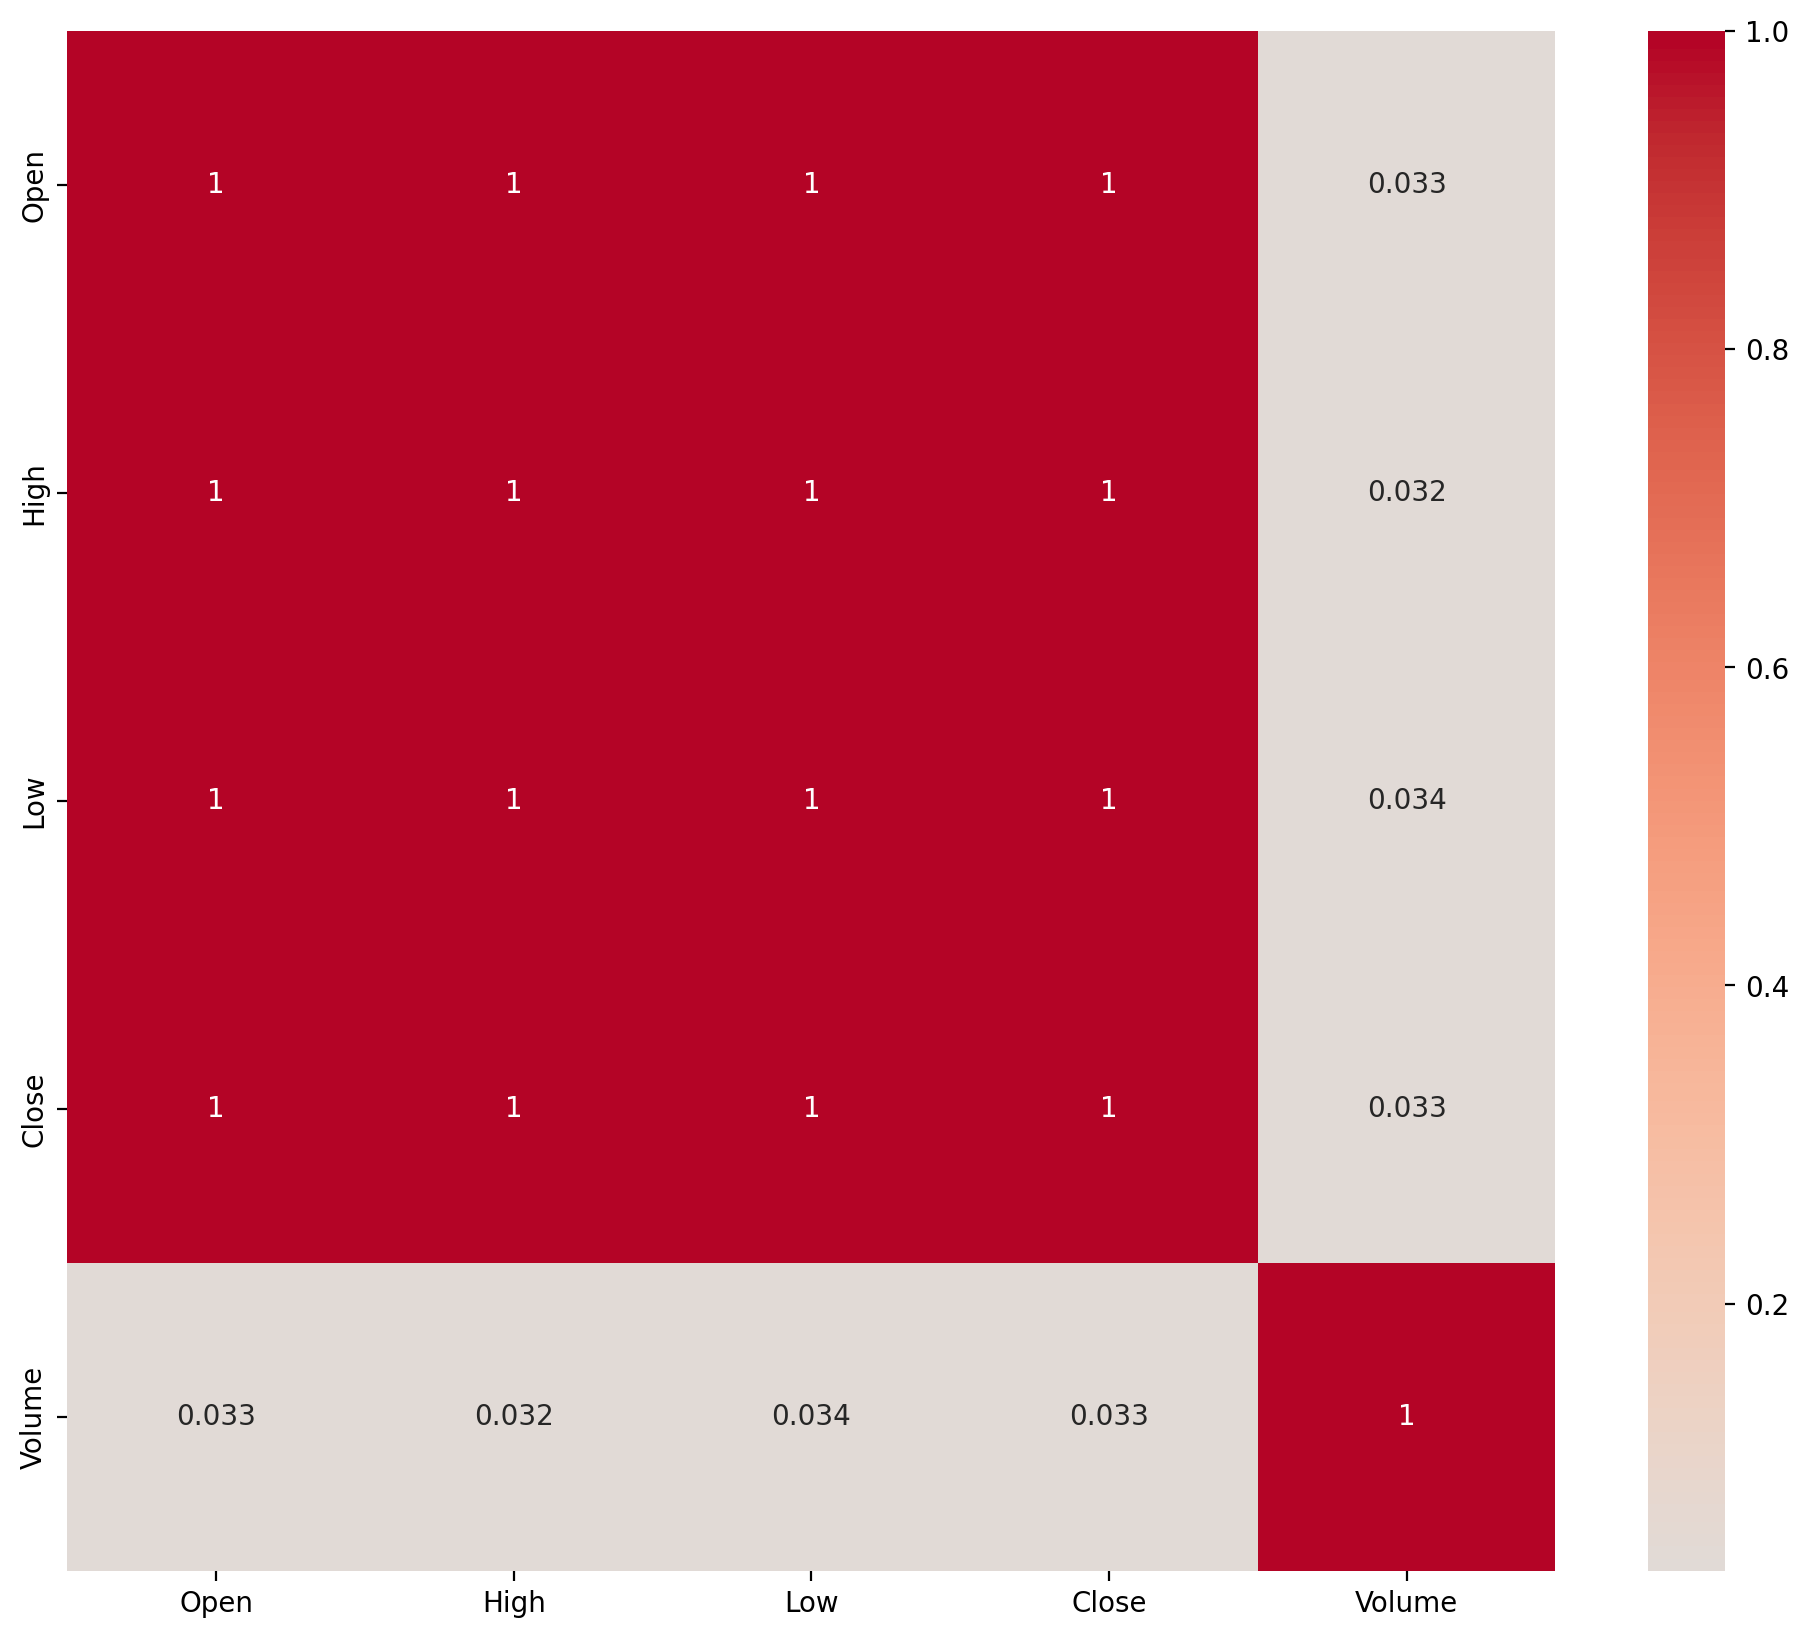

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);